<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Özlem Salehi Köken
        </td>        
</tr></table>

# <font color="blue"> Solutions for </font>  Quantum Approximate Optimization Algorithm - Implementation

<a id="Task1"></a>

### Task 1

Complete the function below that creates the initial state given the number of qubits in the circuit.




In [ ]:
from qiskit import  QuantumCircuit

def initial_state(n):
  ### Your code here


  return qc

### Solution

In [ ]:
from qiskit import  QuantumCircuit

def initial_state(n):
  qc = QuantumCircuit(n)
  for i in range(n):
    qc.h(i)
  return qc

<a id="Task2"></a>


### Task 2



Complete the function below that creates the mixer given the number of qubits in the circuit. The function takes the number of qubits and the layer number as input. The circuit should be parametrized by $\beta_i$ where $i$ is the layer number.

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def mixer(n, i):
  ### Your code here


  return qc

### Solution

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def mixer(n, i):
  qc = QuantumCircuit(n)
  beta = Parameter(f'beta{i}')
  for j in range(n):
    qc.rx(2*beta,j)
  return qc

<a id="Task3"></a>

### Task 3

Complete the function below that implements ansatz for the given cost Hamiltonian which is guaranteed to be 2-local. The function takes the number of qubits, the Hamiltonian, and the layer number as input. The circuit should be parametrized by $\gamma_i$, where $i$ is the layer number.

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def cost(n, op, i):

  ### Your code here

  return qc

### Solution

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def cost(n, op, i):
  qc = QuantumCircuit(n)
  gamma = Parameter(f"gamma{i}")
  for term in op:
    indices = [k for k, p in enumerate(term.paulis[0]) if str(p) != "I"]
    if len(indices) == 2:
      qc.rzz(2*term.coeffs[0].real*gamma, *indices)
    elif len(indices) == 1:
      qc.rz(2*term.coeffs[0].real*gamma, *indices)
  return qc

<a id="Task4"></a>


### Task 4

Extend the function you have written in Task 3 by also taking into account Hamiltonians which are not 2-local.

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def cost(n, op, i):
  ### Your code here

  return qc

### Solution

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def cost(n, op, i):
  qc = QuantumCircuit(n)
  gamma = Parameter(f"gamma{i}")
  for term in op:
    indices = [k for k, p in enumerate(term.paulis[0]) if str(p) != "I"]
    if len(indices) > 2:
      for k in range(len(indices)-1):
        qc.cx(indices[k],indices[k+1])
      qc.rz(2*term.coeffs[0].real*gamma, indices[-1])
      for k in range(len(indices)-1, 0, -1):
        qc.cx(indices[k-1], indices[k])
    if len(indices) == 2:
      qc.rzz(2*term.coeffs[0].real*gamma, *indices)
    elif len(indices) == 1:
      qc.rz(2*term.coeffs[0].real*gamma, *indices)
    qc.barrier()
  return qc

<a id="Task5"></a>

### Task 5

For the Hamiltonian $H= 2ZZZI + 4IZZI + IIIZ + ZIIZ$, verify the correctness of the circuit construction you made in Task 4, by exact diagonalization. Note that function `cost` returns a parametrized circuit and you should assign parameters before obtaining the unitary circuit. Assume that we are in the first layer and assign $\gamma_0=1$

In [ ]:
from qiskit.quantum_info import SparsePauliOp

H =  SparsePauliOp(["ZZZI","IZZI","IIIZ", "ZIIZ"], [2,4,1,1])
qc = cost(4,H,0)

### Your code here

In [ ]:
import numpy as np
from scipy.linalg import eig

### Your code here

U2 = P @ expD @ P_inv

In [ ]:
assert np.allclose(U1,U2)

### Solution

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator

H =  SparsePauliOp(["ZZZI","IZZI","IIIZ", "ZIIZ"], [2,4,1,1])
qc = cost(4,H,0)
bc = qc.assign_parameters([1])
U1 = Operator.from_circuit(bc)


In [ ]:
import numpy as np
from scipy.linalg import eig

eigenvalues, eigenvectors = eig(H)
P = eigenvectors
D = np.diag(eigenvalues)
P_inv = np.linalg.inv(P)
t = 1
expD = np.diag(np.exp(-1j * t * np.diagonal(D)))
U2 = P @ expD @ P_inv

In [ ]:
assert np.allclose(U1,U2)

<a id="Task6"></a>

### Task 6

For the Hamiltonian $H= 2ZZZI + 4IZZI + IIIZ + ZIIZ$, create its QAOA circuit with 5 layers and draw it.

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

n = 4
p = 5
H =  SparsePauliOp(["ZZZI","IZZI","IIIZ", "ZIIZ"], [2,4,1,1])
#Create the circuit

#Add initial state

qc.barrier()
for i in range(p):
  # Add mixer

  qc.barrier()
  # Add cost Hamiltonian

  qc.barrier()
qc.decompose().draw(output="mpl")

### Solution

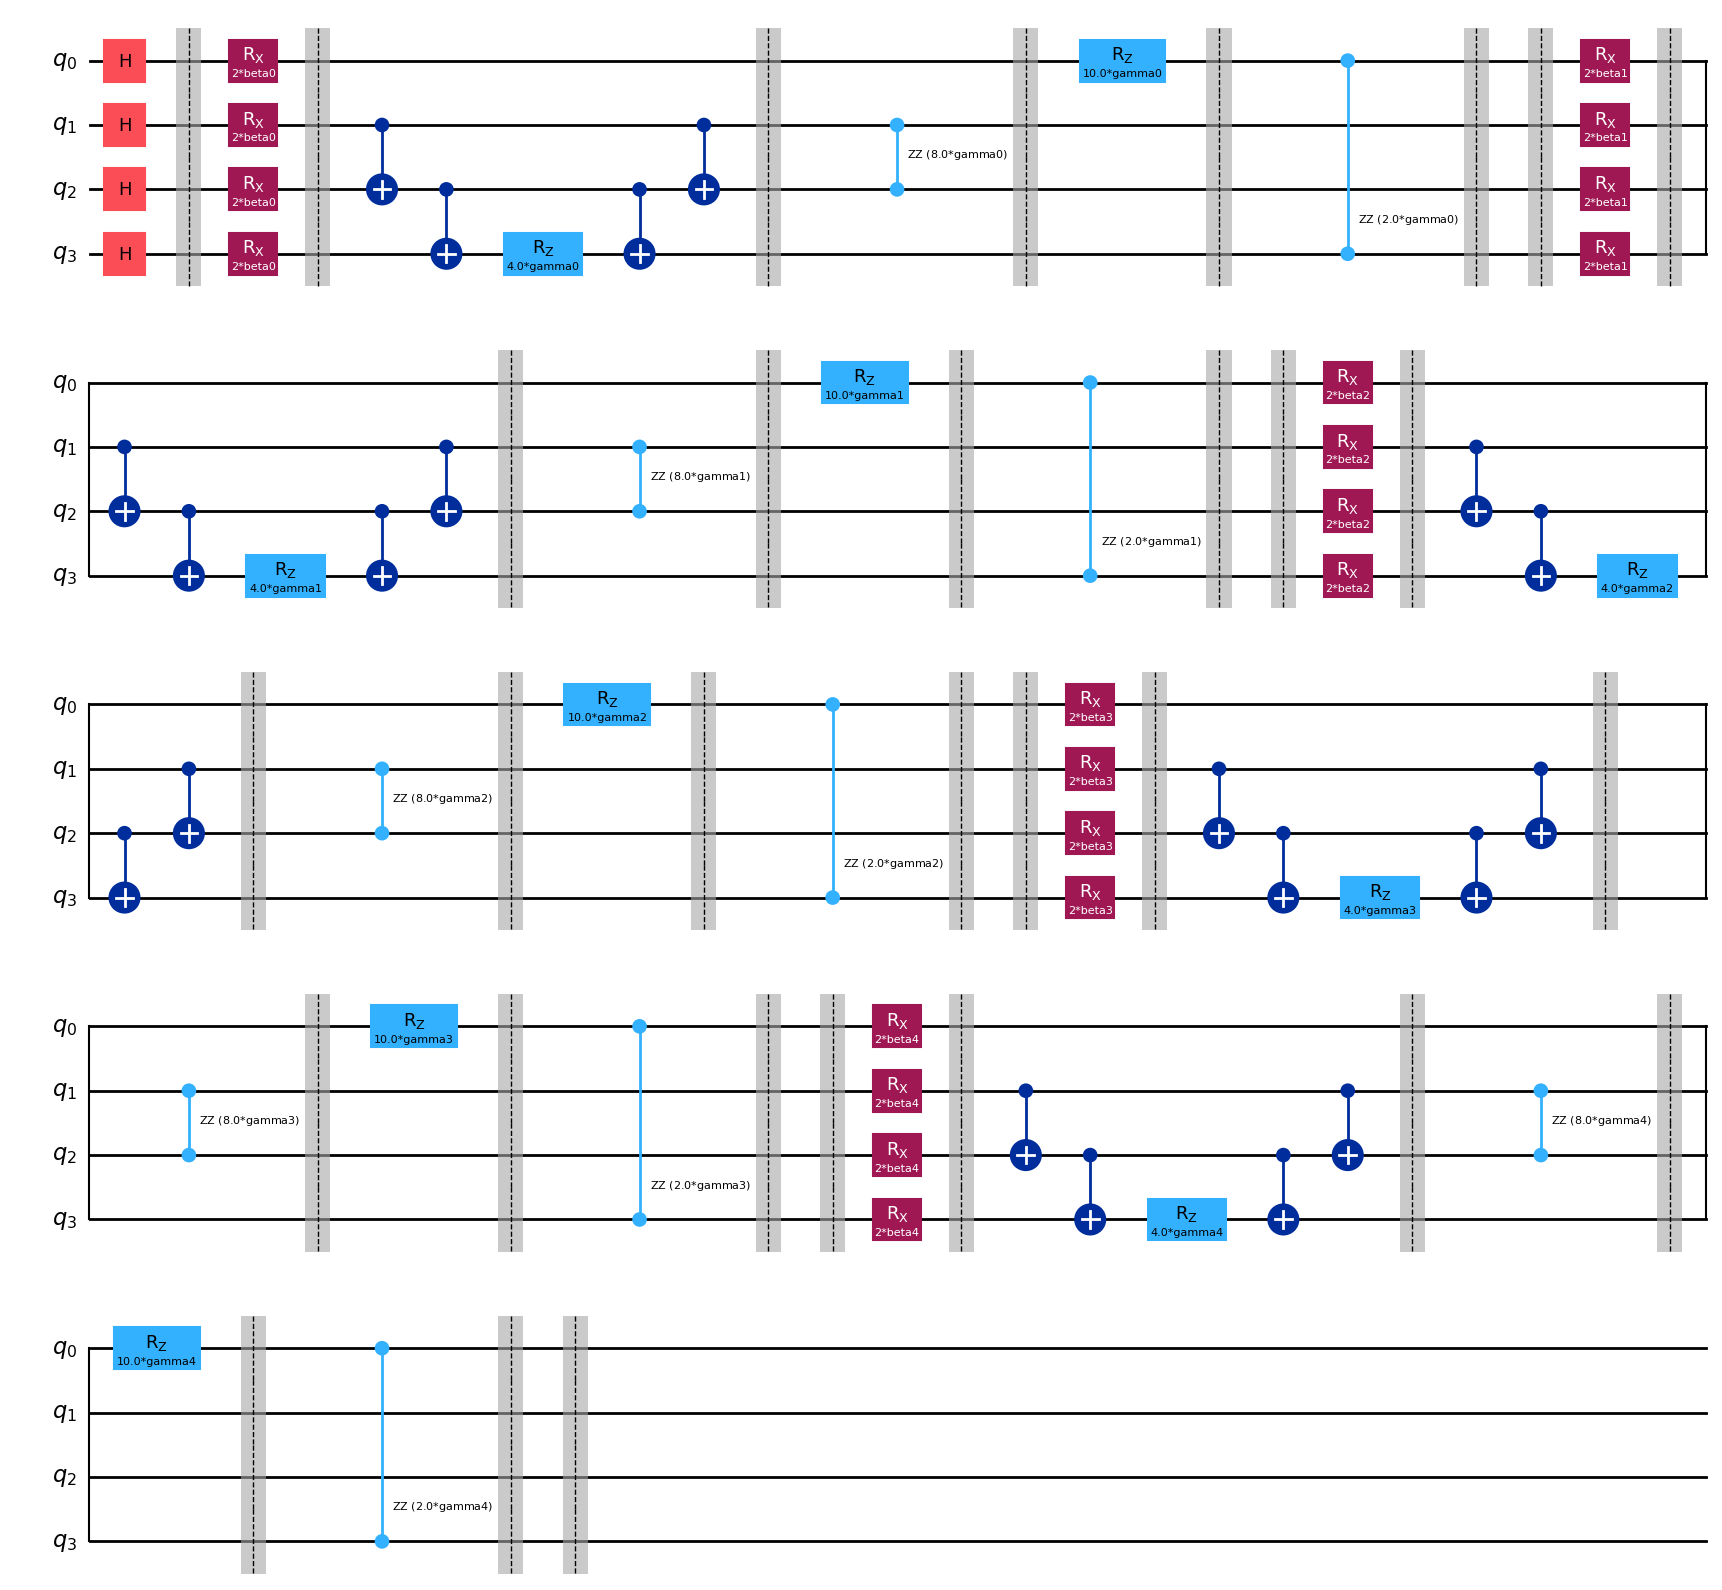

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

n = 4
p = 5
H =  SparsePauliOp(["ZZZI","IZZI","IIIZ", "ZIIZ"], [2,4,1,1])
#Create the circuit
qc = QuantumCircuit(n)
#Add initial state
qc.append(initial_state(n), range(n))
qc.barrier()
for i in range(p):
  # Add mixer
  qc.append(mixer(n,i), range(n))
  qc.barrier()
  # Add cost Hamiltonian
  qc.append(cost(n,H,i), range(n))
  qc.barrier()
qc.decompose().draw(output="mpl")